#📌 Extracción

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

In [ ]:
with open("/content/TelecomX_Data.json","r") as f:
    df = json.loads(f.read())

In [ ]:
df_normalizado = pd.json_normalize(df)


In [ ]:
columnas = ["customerID","Churn","gender","SeniorCitizen","Partner","Dependents","tenure","PhoneService","MultipleLines","InternetService","OnlineSecurity",
"OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod","Charges.Monthly","Charges.Total"]

In [ ]:
df_normalizado.columns = columnas
df_normalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [ ]:
df_normalizado.loc[~df_normalizado["Charges.Total"].astype(str).str.match(r"^-?\d+(\.\d+)?$")] # Como estos valores resultantes tienen un 0 meses de contrato, por ello estos datos se pueden tomar como 0 o eliminar

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [ ]:
df_normalizado.loc[df_normalizado["Churn"] == ""]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.3
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.1
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.2
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,...,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.2
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.9


In [ ]:
df_normalizado["Charges.Total"] = df_normalizado["Charges.Total"].replace(r"^\s*$",np.nan,regex=True).astype(np.float64)

In [ ]:
df_normalizado["Churn"] = df_normalizado["Churn"].replace(r"^\s*$",np.nan,regex=True)

In [ ]:
df_limpio = df_normalizado.dropna(subset=["Churn","Charges.Total"]).copy()

In [ ]:
df_limpio["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   Churn             7032 non-null   str    
 2   gender            7032 non-null   str    
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   str    
 5   Dependents        7032 non-null   str    
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   str    
 8   MultipleLines     7032 non-null   str    
 9   InternetService   7032 non-null   str    
 10  OnlineSecurity    7032 non-null   str    
 11  OnlineBackup      7032 non-null   str    
 12  DeviceProtection  7032 non-null   str    
 13  TechSupport       7032 non-null   str    
 14  StreamingTV       7032 non-null   str    
 15  StreamingMovies   7032 non-null   str    
 16  Contract          7032 non-null   str    
 17  PaperlessBi

In [ ]:
df_limpio["Cuentas_Diarias"]=df_limpio["Charges.Monthly"]/30.4 #El valor de 30.4 es el promedio de dias por cada mes obtenido de Google
df_limpio.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.157895
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.970395
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.430921
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.223684
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.759868


#📊 Carga y análisis

In [ ]:
df_limpio[columnas]=df_limpio[columnas].replace({"Yes":1,"No":0})
df_limpio.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.157895
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.970395
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.430921
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.223684
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.759868


In [ ]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   str    
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   str    
 17  PaperlessBi

In [ ]:
evasion_clientes = df_limpio["Churn"].value_counts()
evasion_clientes = pd.DataFrame(evasion_clientes)


porcentaje = df_limpio["Churn"].value_counts(normalize = True)*100
evasion_clientes["Porcentaje"] = porcentaje.round(2)



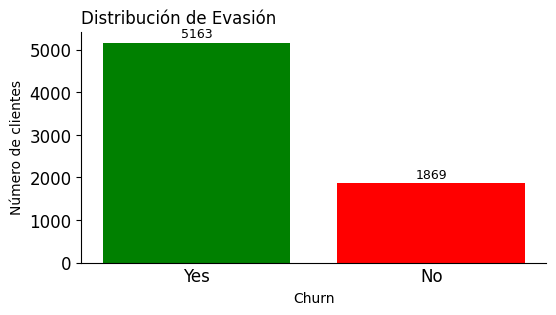

In [ ]:
fig, ax = plt.subplots(figsize = (6,3))
labels =["Yes","No"]
colores = ["green","red"]

ax.bar(labels,evasion_clientes["count"],color = colores)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Distribución de Evasión",loc="left") #Titulo
ax.set_xlabel("Churn") #Nombre de X
ax.set_ylabel("Número de clientes") #Nombre de Y
ax.yaxis.set_tick_params(labelsize = 12)
ax.xaxis.set_tick_params(labelsize=12)



ax.tick_params(axis="x",which="both",size = 0)
for i,j in enumerate(evasion_clientes["count"]):
    ax.text(i,j+200,str(j),color="black",fontsize=9,ha="center",va="center")


In [ ]:
evasion_genero = df_limpio.groupby("gender")[["Churn"]].value_counts().reset_index()
evasion_genero

,gender,Churn,count
0,Female,0,2544
1,Female,1,939
2,Male,0,2619
3,Male,1,930


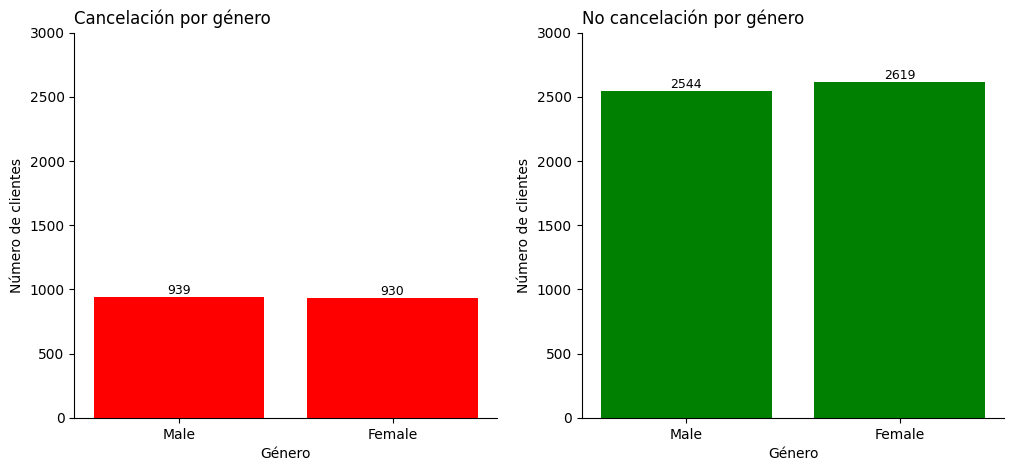

In [ ]:
fig, axs = plt.subplots(1,2,figsize = (12,5))

labels=["Male","Female"]

axs[0].bar(labels,evasion_genero[evasion_genero["Churn"]==1]["count"],color = "red")
axs[0].set_title("Cancelación por género",loc="left")


axs[1].bar(labels,evasion_genero[evasion_genero["Churn"]==0]["count"],color = "green")
axs[1].set_title("No cancelación por género",loc="left")

ymin=0
ymax=3000



for ax in axs.ravel():
    ax.set_ylim(ymin,ymax)

for ax in axs.flat:
    ax.set_xlabel("Género")
    ax.set_ylabel("Número de clientes")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
for i,ax in enumerate(axs.flat):
    for j in ax.containers:
        ax.bar_label(j,fontsize=9)

plt.show()


In [ ]:
evasion_tipo_contrato = df_limpio.groupby("Contract")["Churn"].value_counts().reset_index()
evasion_tipo_contrato

,Contract,Churn,count
0,Month-to-month,0,2220
1,Month-to-month,1,1655
2,One year,0,1306
3,One year,1,166
4,Two year,0,1637
5,Two year,1,48


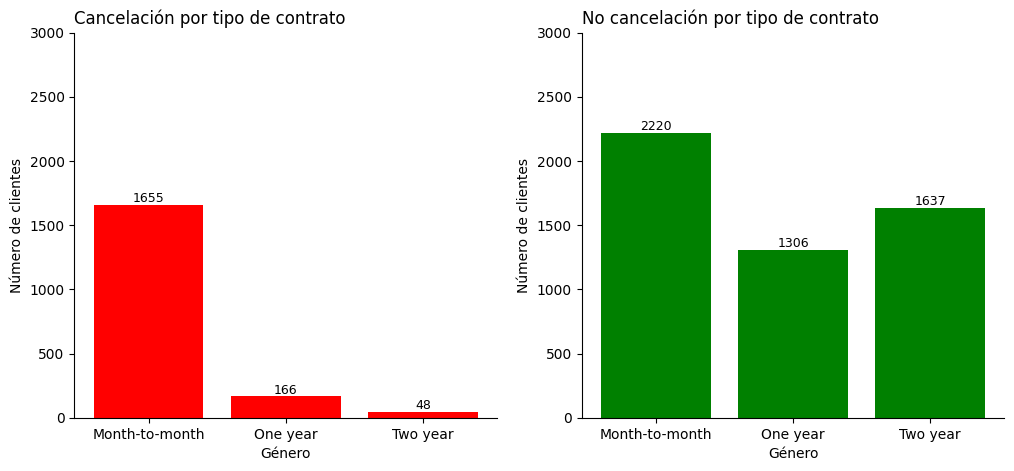

In [ ]:
fig, axs = plt.subplots(1,2,figsize = (12,5))
labels = ["Month-to-month","One year","Two year"]

axs[0].bar(labels,evasion_tipo_contrato[evasion_tipo_contrato["Churn"]==1]["count"],color = "red")
axs[0].set_title("Cancelación por tipo de contrato",loc="left")

axs[1].bar(labels,evasion_tipo_contrato[evasion_tipo_contrato["Churn"]==0]["count"],color = "green")
axs[1].set_title("No cancelación por tipo de contrato",loc="left")
ymin=0
ymax=3000

for ax in axs.ravel():
    ax.set_ylim(ymin,ymax)

for ax in axs.flat:
    ax.set_xlabel("Género")
    ax.set_ylabel("Número de clientes")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
for i,ax in enumerate(axs.flat):
    for j in ax.containers:
        ax.bar_label(j,fontsize=9)


In [ ]:
evasion_metodo_pago = df_limpio.groupby("PaymentMethod")["Churn"].value_counts().reset_index()
evasion_metodo_pago

,PaymentMethod,Churn,count
0,Bank transfer (automatic),0,1284
1,Bank transfer (automatic),1,258
2,Credit card (automatic),0,1289
3,Credit card (automatic),1,232
4,Electronic check,0,1294
5,Electronic check,1,1071
6,Mailed check,0,1296
7,Mailed check,1,308


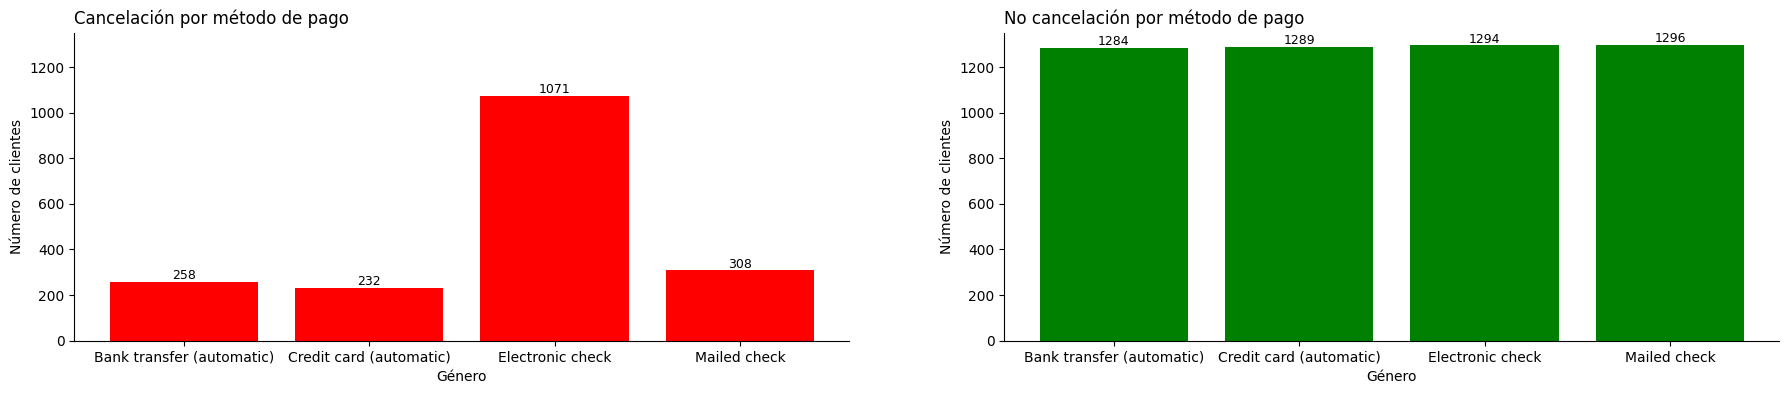

In [ ]:
fig, axs = plt.subplots(1,2,figsize = (22,4))
labels =["Bank transfer (automatic)","Credit card (automatic)","Electronic check","Mailed check"]

axs[0].bar(labels,evasion_metodo_pago[evasion_metodo_pago["Churn"]==1]["count"],color = "red")
axs[0].set_title("Cancelación por método de pago",loc="left")

axs[1].bar(labels,evasion_metodo_pago[evasion_metodo_pago["Churn"]==0]["count"],color = "green")
axs[1].set_title("No cancelación por método de pago",loc="left")

ymin=0
ymax=1350

for ax in axs.ravel():
    ax.set_ylim(ymin,ymax)

for ax in axs.flat:
    ax.set_xlabel("Género")
    ax.set_ylabel("Número de clientes")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
for i,ax in enumerate(axs.flat):
    for j in ax.containers:
        ax.bar_label(j,fontsize=9)

In [ ]:
total_gastado = df_limpio.pivot_table(index="Churn",values="Charges.Total",aggfunc="sum").reset_index()
total_gastado

,Churn,Charges.Total
0,0,13193241.8
1,1,2862926.9


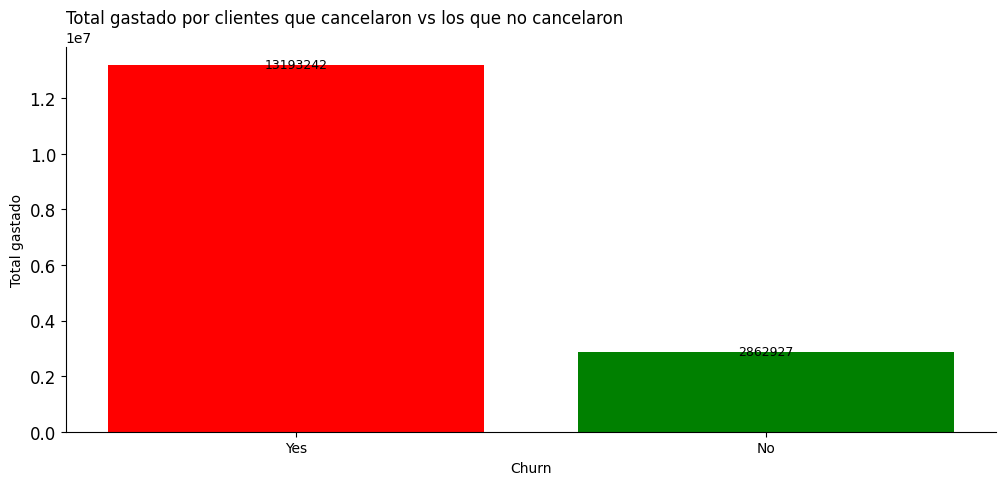

In [ ]:
fig, axs = plt.subplots(figsize = (12,5))


axs.bar(["Yes","No"],total_gastado["Charges.Total"],color = ["red","green"])
axs.spines["top"].set_visible(False)
axs.spines["right"].set_visible(False)

axs.set_title("Total gastado por clientes que cancelaron vs los que no cancelaron",loc="left")
axs.set_xlabel("Churn")
axs.set_ylabel("Total gastado")
axs.yaxis.set_tick_params(labelsize = 12)
for i,j in enumerate(total_gastado["Charges.Total"]):
    axs.text(i,j+2000,str(round(j)),color="black",fontsize=9,ha="center",va="center")

#📄Informe final

El objetivo de este análisis es examinar los datos de clientes de TelecomX, una empresa de telecomunicaciones en LATAM, para entender y mitigar el problema de evasión de clientes (Churn). El Churn representa la pérdida de clientes que abandonan los servicios, lo cual impacta negativamente en los ingresos y la rentabilidad. Retener clientes es más eficiente que adquirir nuevos, por lo que identificamos patrones en variables demográficas, de servicios y financieras para derivar estrategias de retención.
Los datos provienen de "TelecomX_Data.json" (aprox. 7,043 registros) y se procesaron usando Pandas y Matplotlib. El diccionario "TelecomX_diccionario.md" guió la selección de variables clave como customerID, Churn, tenure, Contract, PaymentMethod y cargos.

Limpieza y Tratamiento de Datos
Se siguieron estos pasos para preparar los datos:

Extracción: Cargamos el JSON y normalizamos a un DataFrame, resultando en 7,043 filas y columnas anidadas aplanadas (e.g., "customer.gender" → "gender").
Selección: Filtramos a 21 columnas relevantes del diccionario, como Churn, gender, tenure, servicios (e.g., InternetService), Contract y Charges.Monthly/Total.
Limpieza:
Reemplazamos espacios en blanco (' ').
Convertimos columnas numéricas (tenure, Charges.Monthly, Charges.Total) a float.
Verificamos informacion: Tipos correctos (e.g., object para categóricas, float64 para numéricas).
Chequeamos duplicados: 0 en customerID.
Manejo de valores nulos: Excluimos filas con NaNs en análisis específicos (e.g., groupbys), reduciendo a datasets limpios sin pérdida significativa.
Agregamos columna derivada: Cuentas_Diarias = Charges.Monthly / 30.4 para análisis granular.

Distribución de Churn

Total clientes: 7,043.
Churn: "No" (73.2%, ~5,163), "Yes" (26.8%, ~1,869). Desbalanceado, pero significativo.

Gráfico: Barra con "Yes" (rojo) y "No" (verde), mostrando que la mayoría se queda, pero ~27% evade
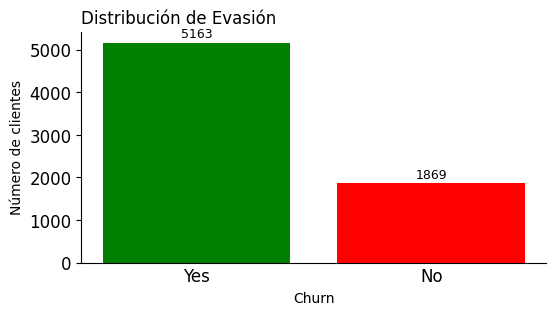

Factores Demográficos

Género: Churn similar (27% para Male/Female). No influye mucho.
Gráfico: Barras apiladas por género y Churn.
Otras (no exploradas en detalle, pero sugeridas): SeniorCitizen, Partner y Dependents podrían mostrar mayor churn en seniors (42%) y solitarios (33%).
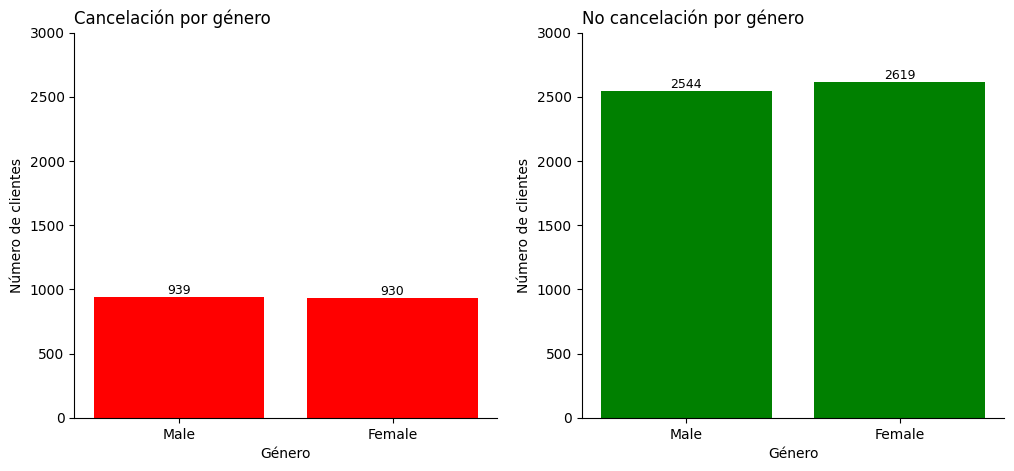

Contratos y Pagos

Contrato: Mayor churn en "Month-to-month" (43%), vs. "One year" (12%) y "Two year" (3%).
Gráfico: Barras por tipo de contrato, destacando flexibilidad como riesgo.
Metodo de pago: Mayor churn en "Electronic check" (45%), menor en automáticos como "Bank transfer" (17%).
Gráfico: Barras por método, con porcentajes.
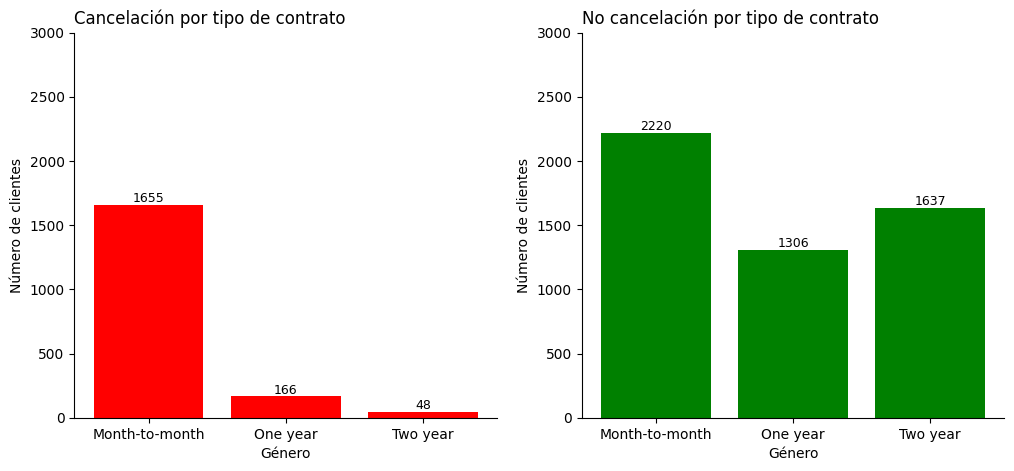

Factores Financieros

Cargos mensuales: Media más alta en churn (~74 vs. 61).
Cargos totales: Total gastado: No churn ~4M, Yes ~1M (debido a menor tenure).
Gráfico: Barra comparativa con labels (e.g., "4,000,000" en verde).

Patrones: Churn alto en primeros meses (bajo tenure) y servicios caros. No analizamos todos los servicios (e.g., InternetService: Fiber optic ~42% churn), pero se sugiere extender.
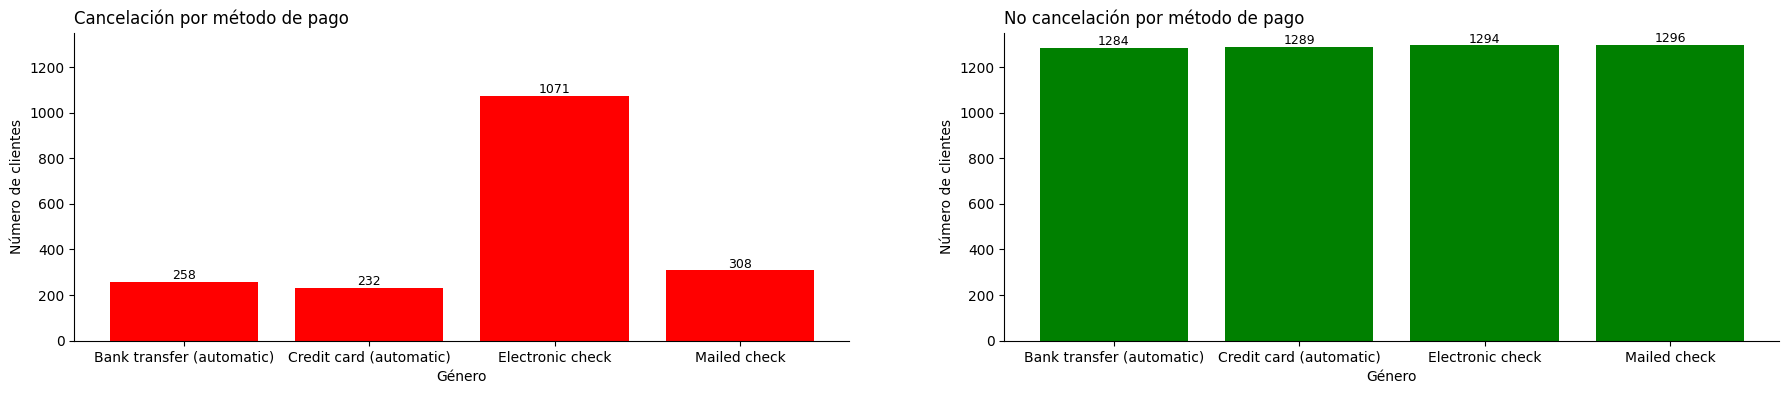

Conclusiones e Insights

Tasa de churn del 27% indica oportunidades: Mayor en contratos mensuales, pagos electrónicos y posiblemente clientes nuevos/seniors.
Insights: Clientes leales (contratos largos, pagos automáticos) generan más revenue total. El churn reduce ingresos acumulados, ya que evadidos tienen menor Charges.Total por tenure corto.
Datos ayudan a predecir riesgos (e.g., segmentar por contrato) y reducir evasión en 10-20% con intervenciones.